In [2]:
import pandas as pd
df=pd.read_csv('Zomato-data- (1).csv')
df

,name,online_order,book_table,rate,votes,approx_cost(for two people),listed_in(type)
0,Jalsa,Yes,Yes,4.1/5,775,800,Buffet
1,Spice Elephant,Yes,No,4.1/5,787,800,Buffet
2,San Churro Cafe,Yes,No,3.8/5,918,800,Buffet
3,Addhuri Udupi Bhojana,No,No,3.7/5,88,300,Buffet
4,Grand Village,No,No,3.8/5,166,600,Buffet
...,...,...,...,...,...,...,...
143,Melting Melodies,No,No,3.3/5,0,100,Dining
144,New Indraprasta,No,No,3.3/5,0,150,Dining
145,Anna Kuteera,Yes,No,4.0/5,771,450,Dining
146,Darbar,No,No,3.0/5,98,800,Dining


In [3]:
df.head()

,name,online_order,book_table,rate,votes,approx_cost(for two people),listed_in(type)
0,Jalsa,Yes,Yes,4.1/5,775,800,Buffet
1,Spice Elephant,Yes,No,4.1/5,787,800,Buffet
2,San Churro Cafe,Yes,No,3.8/5,918,800,Buffet
3,Addhuri Udupi Bhojana,No,No,3.7/5,88,300,Buffet
4,Grand Village,No,No,3.8/5,166,600,Buffet


In [4]:
df.describe()

,votes,approx_cost(for two people)
count,148.000000,148.000000
mean,264.810811,418.243243
std,653.676951,223.085098
min,0.000000,100.000000
25%,6.750000,200.000000
50%,43.500000,400.000000
75%,221.750000,600.000000
max,4884.000000,950.000000


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 148 entries, 0 to 147
Data columns (total 7 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   name                         148 non-null    object
 1   online_order                 148 non-null    object
 2   book_table                   148 non-null    object
 3   rate                         148 non-null    object
 4   votes                        148 non-null    int64 
 5   approx_cost(for two people)  148 non-null    int64 
 6   listed_in(type)              148 non-null    object
dtypes: int64(2), object(5)
memory usage: 8.2+ KB


In [6]:
df.isnull().sum()  

name                           0
online_order                   0
book_table                     0
rate                           0
votes                          0
approx_cost(for two people)    0
listed_in(type)                0
dtype: int64

In [7]:
df[['votes','approx_cost(for two people)']].corr()  

,votes,approx_cost(for two people)
votes,1.000000,0.324372
approx_cost(for two people),0.324372,1.000000


#### Data Cleaning

In [8]:
# Remove '/5' and convert to float, coerce errors to NaN
df['rate_clean'] = df['rate'].str.replace('/5','', regex=False)  # remove /5
df['rate_clean'] = pd.to_numeric(df['rate_clean'], errors='coerce')  # convert to float, invalids become NaN

# Now check correlation
df[['votes','rate_clean']].corr()

,votes,rate_clean
votes,1.000000,0.489844
rate_clean,0.489844,1.000000


In [9]:
df['votes'] = pd.to_numeric(df['votes'], errors='coerce')

In [10]:
df_clean = df.dropna(subset=['votes','rate_clean'])

#### Distribution of Ratings:

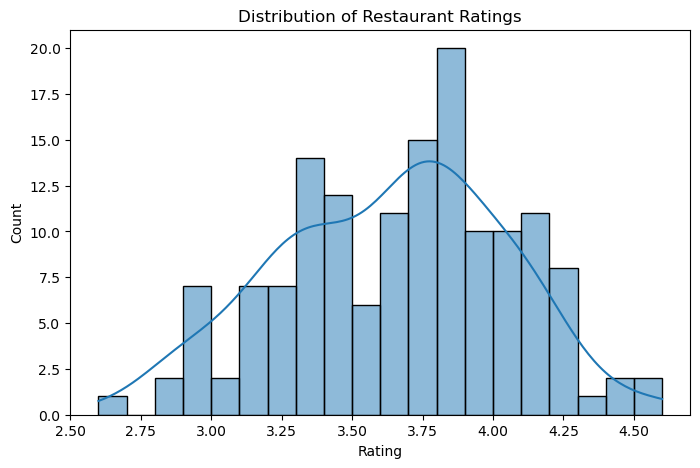

In [15]:
import seaborn as sns
plt.figure(figsize=(8,5))
sns.histplot(df_clean['rate_clean'], bins=20, kde=True)
plt.title('Distribution of Restaurant Ratings')
plt.xlabel('Rating')
plt.ylabel('Count')
plt.show()

#### Distribution of Votes:

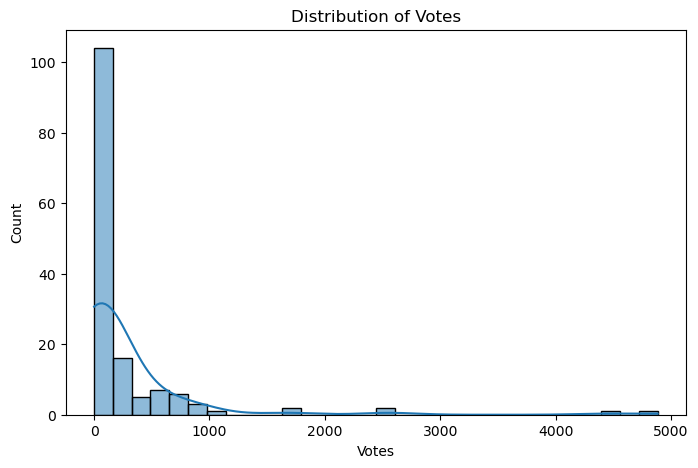

In [16]:
plt.figure(figsize=(8,5))
sns.histplot(df_clean['votes'], bins=30, kde=True)
plt.title('Distribution of Votes')
plt.xlabel('Votes')
plt.ylabel('Count')
plt.show()

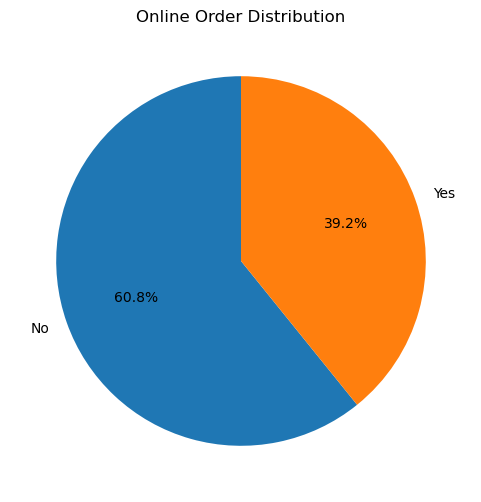

In [14]:
import matplotlib.pyplot as plt

# Count values in a column
data = df['online_order'].value_counts()

# Create pie chart
plt.figure(figsize=(6,6))
plt.pie(data, labels=data.index, autopct='%1.1f%%', startangle=90)

plt.title("Online Order Distribution")
plt.show()

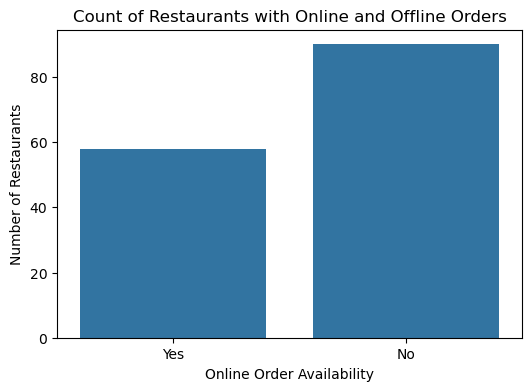

In [17]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))

sns.countplot(x='online_order', data=df)

plt.title("Count of Restaurants with Online and Offline Orders")
plt.xlabel("Online Order Availability")
plt.ylabel("Number of Restaurants")

plt.show()

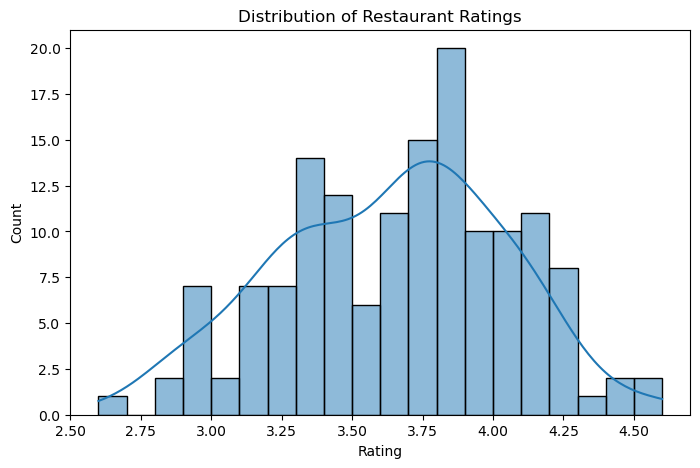

In [26]:
plt.figure(figsize=(8,5))
sns.histplot(df_clean['rate_clean'], bins=20, kde=True)
plt.title('Distribution of Restaurant Ratings')
plt.xlabel('Rating')
plt.ylabel('Count')
plt.show()

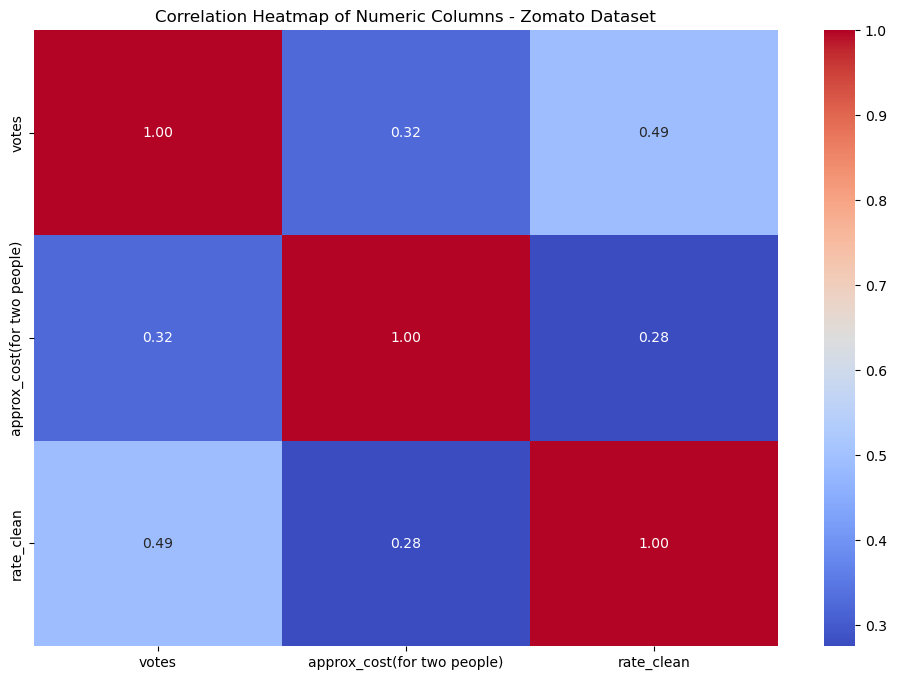

In [32]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load dataset
df = pd.read_csv('Zomato-data- (1).csv')

# Clean 'rate' column to numeric
df['rate_clean'] = df['rate'].str.replace('/5','', regex=False)
df['rate_clean'] = pd.to_numeric(df['rate_clean'], errors='coerce')

# Optional: convert other numeric-like columns if needed
# Example: 'votes' should already be numeric, if not:
df['votes'] = pd.to_numeric(df['votes'], errors='coerce')

# Select all numeric columns for correlation
numeric_cols = df.select_dtypes(include='number')

# Compute correlation matrix
corr_matrix = numeric_cols.corr()

# Plot heatmap
plt.figure(figsize=(12,8))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='coolwarm', cbar=True)
plt.title('Correlation Heatmap of Numeric Columns - Zomato Dataset')
plt.show()

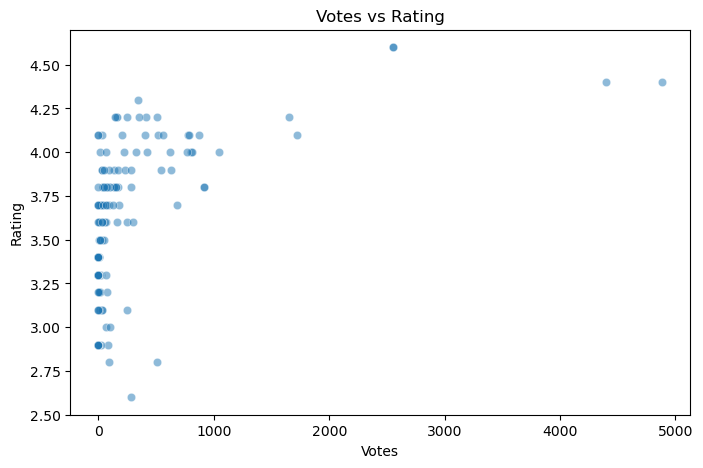

In [33]:
plt.figure(figsize=(8,5))
sns.scatterplot(x='votes', y='rate_clean', data=df_clean, alpha=0.5)
plt.title('Votes vs Rating')
plt.xlabel('Votes')
plt.ylabel('Rating')
plt.show()

#### Outlier Detection

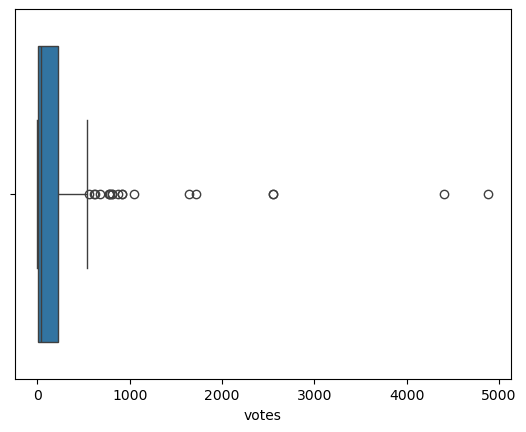

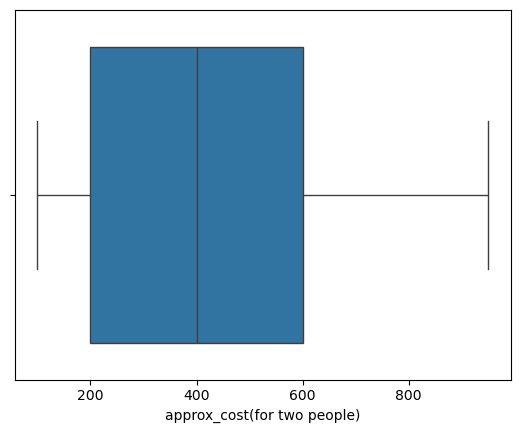

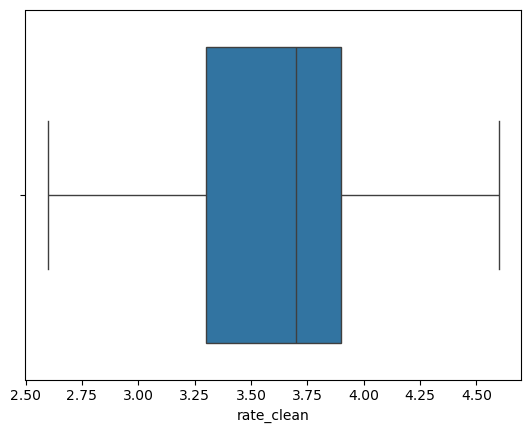

In [38]:
sns.boxplot(x=df['votes'])
plt.show()

sns.boxplot(x=df['approx_cost(for two people)'])
plt.show()

sns.boxplot(x=df['rate_clean'])
plt.show()

#### Outlier Detection Using IQR Method

In [37]:
Q1 = df['votes'].quantile(0.25)
Q3 = df['votes'].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5*IQR
upper = Q3 + 1.5*IQR

outliers = df[(df['votes'] < lower) | (df['votes'] > upper)]
outliers

,name,online_order,book_table,rate,votes,approx_cost(for two people),listed_in(type),rate_clean
0,Jalsa,Yes,Yes,4.1/5,775,800,Buffet,4.1
1,Spice Elephant,Yes,No,4.1/5,787,800,Buffet,4.1
2,San Churro Cafe,Yes,No,3.8/5,918,800,Buffet,3.8
7,Onesta,Yes,Yes,4.6/5,2556,600,Cafes,4.6
14,San Churro Cafe,Yes,No,3.8/5,918,800,Cafes,3.8
37,Szechuan Dragon,Yes,No,4.2/5,1647,600,Dining,4.2
38,Empire Restaurant,Yes,No,4.4/5,4884,750,other,4.4
44,Onesta,Yes,Yes,4.6/5,2556,600,other,4.6
47,Recipe,Yes,No,4.0/5,804,450,Dining,4.0
48,Beijing Bites,Yes,No,3.7/5,679,850,Dining,3.7


 # Conclusion

The Exploratory Data Analysis (EDA) of the Zomato dataset helped us understand important patterns related to restaurant ratings, votes, and pricing. First, the data was cleaned by handling missing values and converting columns like ratings and votes into numeric format. This step ensured the dataset 
was suitable for analysis.

From the analysis, it was observed that most restaurants have ratings between 3.5 and 4.5, which indicates that customers are generally satisfied with the services provided. The votes distribution showed that many restaurants have a low number of votes, while a few popular restaurants receive very high votes.

The cost analysis revealed that most restaurants fall in a moderate price range, making them affordable for many customers. The relationship between votes and ratings suggested that restaurants with more votes tend to have more reliable ratings.

Outlier detection using boxplots and the IQR method showed some extreme values, but many of these represent real popular restaurants rather than data errors. Overall, the EDA provided useful insights into customer preferences, restaurant popularity, and pricing trends, which can help businesses make better decisions.
   
#### Here are some important points
- (1️) Most restaurants allow online ordering
- (2️) Dining restaurants are most common
- (3️) Average cost for two people is moderate
- (4️)  Restaurants with higher votes often have better ratings
- (5️) Some outliers exist in votes and approx_cost
- (6) 40% of restaurants provide online service, while 60% of restaurants provide only offline service.
 - This shows that most restaurants still depend on offline services, while a smaller portion offer online ordering facilities. However, a significant number of restaurants are adopting online services, indicating the growing importance of digital food ordering platforms.